In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [15]:
# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-grid' if 'seaborn-v0_8-grid' in plt.style.available else 'ggplot')

In [16]:
# ==========================================
# 1. DESCARGA DE DATOS
# ==========================================
def descargar_datos(ticker, start_date, end_date):
    """
    Descarga los precios de cierre ajustados desde Yahoo Finance.
    """
    print(f"Descargando datos para {ticker} desde {start_date} hasta {end_date}...")
    df = yf.download(ticker, start=start_date, end=end_date)
    
    if df.empty:
        raise ValueError(f"No se descargaron datos para {ticker}. Revisa el ticker o la conexión.")

    # Selección robusta de precio de cierre ajustado o precio de cierre normal
    if 'Adj Close' in df.columns:
        df = df[['Adj Close']]
    elif 'Close' in df.columns:
        df = df[['Close']]
    else:
        raise KeyError(
            f"No se encontró la columna 'Adj Close' ni 'Close'. Columnas disponibles: {list(df.columns)}"
        )

    df = df.dropna()
    df.columns = ['Close']
    return df

In [17]:
# ==========================================
# 2. TRANSFORMACIÓN A RENDIMIENTOS LOGARÍTMICOS
# ==========================================
def calcular_rendimientos_log(df):
    """
    Calcula los rendimientos logarítmicos diarios.
    La transformación ayuda a estabilizar la media y varianza (Estacionariedad).
    """
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    return df.dropna()

In [18]:
# ==========================================
# 3. ANÁLISIS ESTADÍSTICO (TEST DE DICKEY-FULLER)
# ==========================================
def verificar_estacionariedad(serie, nombre_serie):
    """
    Realiza la prueba de Dickey-Fuller Aumentado (ADF).
    """
    print(f"\n--- Prueba de Estacionariedad (ADF) para {nombre_serie} ---")
    resultado = adfuller(serie)
    print(f"Estadístico ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4e}")
    print("Valores Críticos:")
    for clave, valor in resultado[4].items():
        print(f"   {clave}: {valor:.4f}")
    
    if resultado[1] < 0.05:
        print("Resultado: Se rechaza la hipótesis nula. La serie es ESTACIONARIA.")
    else:
        print("Resultado: No se rechaza la hipótesis nula. La serie NO es estacionaria (posee tendencia).")

In [19]:
# ==========================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ==========================================
def graficar_analisis(df, ticker):
    """
    Genera los gráficos principales de la serie temporal.
    """
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
    
    # Gráfico 1: Precios de Cierre (No Estacionario)
    axes[0].plot(df.index, df['Close'], color='tab:blue', label=f'Precio de Cierre')
    axes[0].set_title(f'{ticker} - Precios de Cierre (Comportamiento No Estacionario)')
    axes[0].set_ylabel('Precio ($)')
    axes[0].legend(loc='upper left')
    
    # Gráfico 2: Rendimientos Logarítmicos (Estacionario / Reversión a la media)
    axes[1].plot(df.index, df['Log_Return'], color='tab:purple', alpha=0.7, label='Rendimiento Log')
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].set_title(f'{ticker} - Rendimientos Logarítmicos Diarios (Propiedades Estacionarias)')
    axes[1].set_ylabel('Rendimiento')
    axes[1].legend(loc='upper left')
    
    # Gráfico 3: Función de Autocorrelación (ACF) para identificar dependencias
    sm.graphics.tsa.plot_acf(df['Log_Return'], lags=40, ax=axes[2], color='tab:red')
    axes[2].set_title('Función de Autocorrelación (ACF) de los Rendimientos')
    axes[2].set_xlabel('Lags (Días)')
    
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed

Descargando datos para SPY desde 2015-01-01 hasta 2026-05-25...

--- Prueba de Estacionariedad (ADF) para Precios de Cierre ---


Estadístico ADF: 1.4470
p-valor: 9.9732e-01
Valores Críticos:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673
Resultado: No se rechaza la hipótesis nula. La serie NO es estacionaria (posee tendencia).

--- Prueba de Estacionariedad (ADF) para Rendimientos Logarítmicos ---
Estadístico ADF: -17.2860
p-valor: 5.7428e-30
Valores Críticos:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673
Resultado: Se rechaza la hipótesis nula. La serie es ESTACIONARIA.


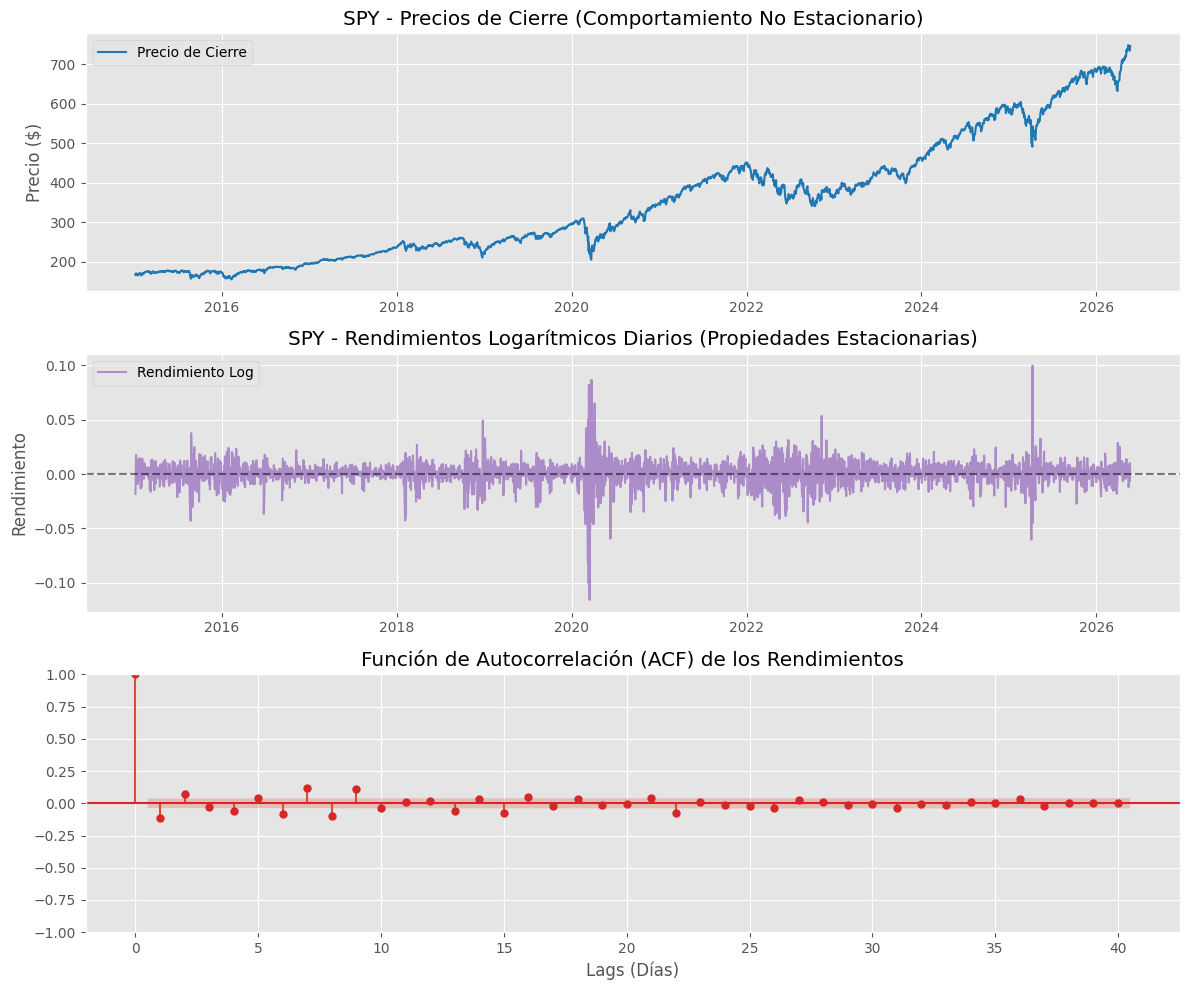

In [22]:
# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================
if __name__ == "__main__":
    # Parámetros de simulación basados en tu rango histórico visualizado
    TICKER = "SPY"
    FECHA_INICIO = "2015-01-01"
    FECHA_FIN = "2026-05-25"
    
    # Flujo de ejecución
    datos_precios = descargar_datos(TICKER, FECHA_INICIO, FECHA_FIN)
    datos_completos = calcular_rendimientos_log(datos_precios)
    
    # Pruebas estadísticas
    verificar_estacionariedad(datos_completos['Close'], "Precios de Cierre")
    verificar_estacionariedad(datos_completos['Log_Return'], "Rendimientos Logarítmicos")
    
    # Renderizado de gráficos de análisis cuantitativo
    graficar_analisis(datos_completos, TICKER)